<a href="https://colab.research.google.com/github/ubaidbme/Brain-Tumor-Classification-using-Machine-Learning-Models/blob/main/Brain_Tumor_Classification_using_Machine_Learning_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dataset Description**

**Dataset Selection**

For this assignment, we have chosen the Brain Tumor MRI Dataset from Kaggle, which is a comprehensive collection of MRI images for brain tumor classification.

Dataset Source: Brain Tumor MRI Dataset on Kaggle.

**Dataset Overview**

This dataset contains 7,023 images of human brain MRI scans classified into four distinct categories:

Class Tumor Type Description Glioma Glioma A type of tumor that occurs in the brain and spinal cord, originating from glial cells Meningioma Meningioma A tumor that arises from the meninges—the membranes that surround the brain and spinal cord Pituitary Pituitary Tumor A tumor that develops in the pituitary gland at the base of the brain No Tumor Healthy MRI scans showing no evidence of tumor Dataset Composition The dataset is a combination of three public datasets:

Figshare dataset: Contains glioma, meningioma, and pituitary tumor images

Br35H dataset: Contributes the "no tumor" class images

SARTAJ dataset: Originally included but problematic glioma images were replaced with Figshare images

**Key Characteristics**
Total Images: 7,023

Image Format: JPEG/PNG

Color Scale: Grayscale/RGB MRI scans

Image Sizes: Varying dimensions (require resizing during preprocessing)

Classes: 4 (glioma, meningioma, pituitary, no tumor)

Why This Dataset?

This dataset is ideal for our comparative study because:

*   Balanced classes: Provides sufficient samples across all four categories
*   Real-world complexity: Images come from different sources with varying characteristics
*    Established benchmark: Widely used in brain tumor classification research

*   Challenging task: Requires models to distinguish between subtle visual differences
*   Clinical relevance: Addresses a real-world medical imaging problem
  



# **Setup and Dependencies**

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn for ML models and evaluation
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# TensorFlow/Keras for deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# For feature extraction
from skimage.feature import local_binary_pattern, hog
from skimage import exposure

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Check for GPU availability
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: []


# **Data Loading and Exploration**

Mounted at /content/drive
Training set distribution:
  glioma: 1400 images
  meningioma: 1400 images
  pituitary: 1400 images
  notumor: 1400 images


Testing set distribution:
  glioma: 400 images
  meningioma: 400 images
  pituitary: 400 images
  notumor: 400 images


Total training images: 5600
Total testing images: 1600
Total dataset size: 7200 images


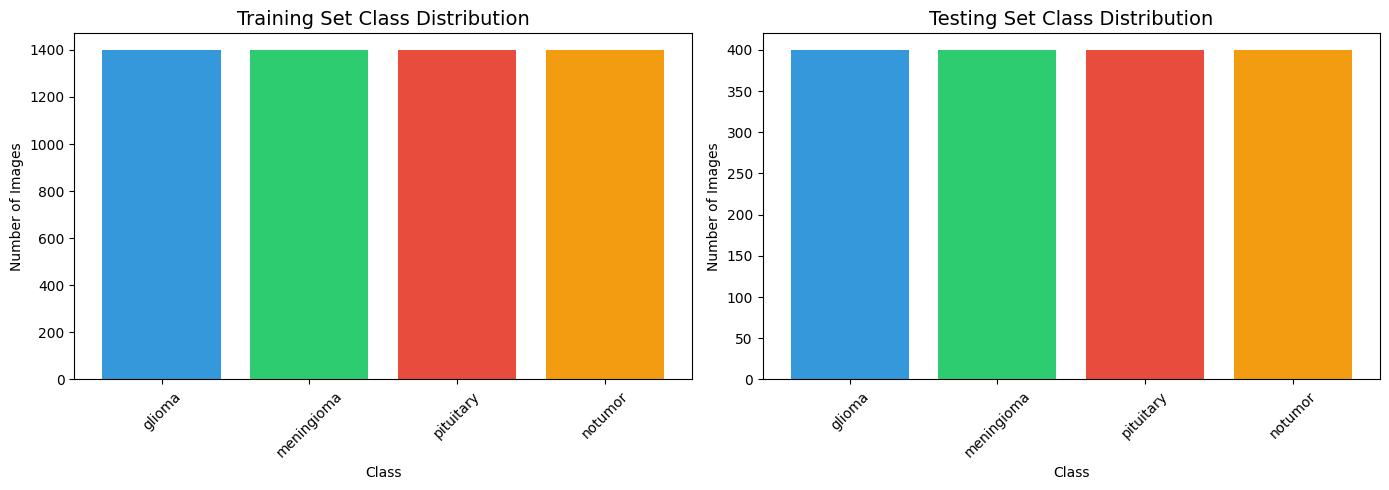

In [2]:
# Define paths
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
data_dir = '/content/drive/MyDrive/Datasets/masoudnickparvar/brain-tumor-mri-dataset'
training_dir = os.path.join(data_dir, 'Training')
testing_dir = os.path.join(data_dir, 'Testing')

# Class names
class_names = ['glioma', 'meningioma', 'pituitary', 'notumor']
class_labels = {0: 'glioma', 1: 'meningioma', 2: 'pituitary', 3: 'notumor'}

# Function to count images in each class
def count_images(base_dir, classes):
    counts = {}
    for class_name in classes:
        class_path = os.path.join(base_dir, class_name)
        if os.path.exists(class_path):
            counts[class_name] = len(os.listdir(class_path))
        else:
            counts[class_name] = 0
    return counts

# Count images in training set
train_counts = count_images(training_dir, class_names)
print("Training set distribution:")
for class_name, count in train_counts.items():
    print(f"  {class_name}: {count} images")

print("\n" + "="*50 + "\n")

# Count images in testing set
test_counts = count_images(testing_dir, class_names)
print("Testing set distribution:")
for class_name, count in test_counts.items():
    print(f"  {class_name}: {count} images")

# Calculate total
total_train = sum(train_counts.values())
total_test = sum(test_counts.values())
total_images = total_train + total_test

print("\n" + "="*50 + "\n")
print(f"Total training images: {total_train}")
print(f"Total testing images: {total_test}")
print(f"Total dataset size: {total_images} images")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training distribution
axes[0].bar(train_counts.keys(), train_counts.values(), color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
axes[0].set_title('Training Set Class Distribution', fontsize=14)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=45)

# Testing distribution
axes[1].bar(test_counts.keys(), test_counts.values(), color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
axes[1].set_title('Testing Set Class Distribution', fontsize=14)
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Number of Images')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

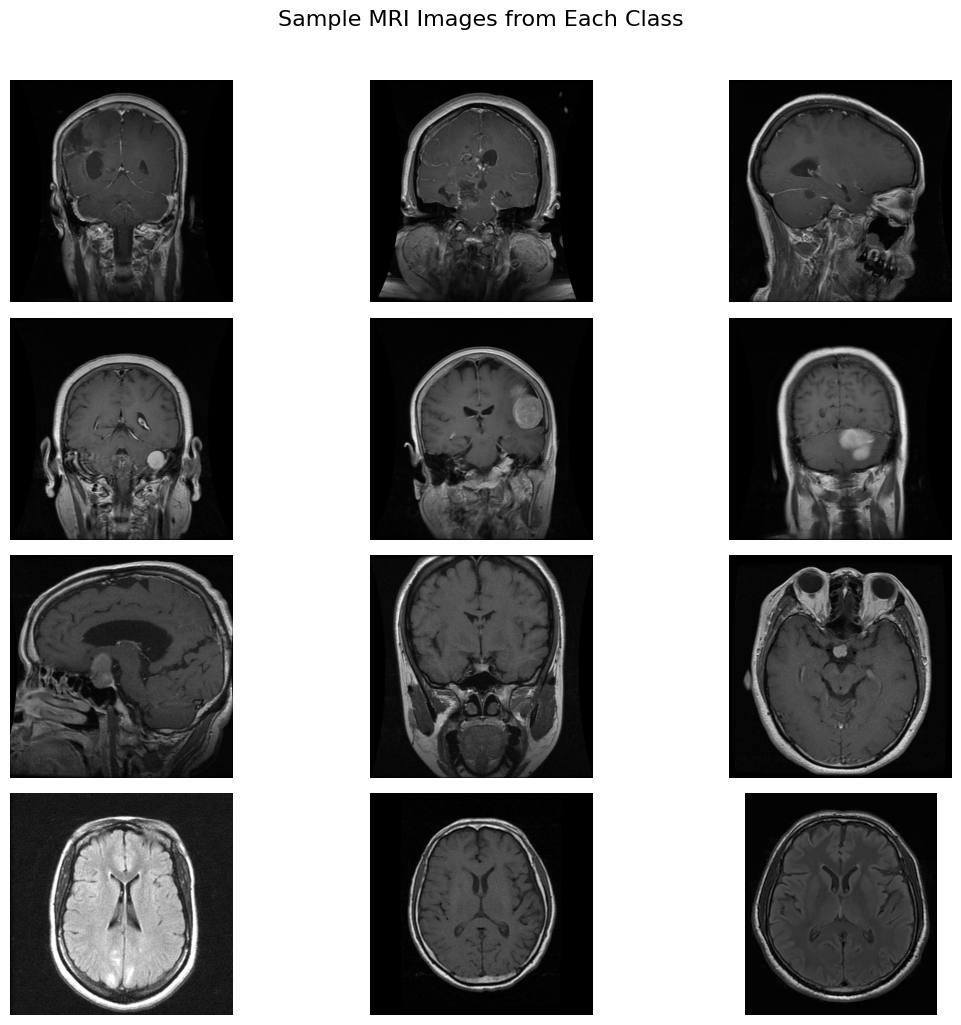

In [3]:
# Visualize sample images from each class
def plot_sample_images(base_dir, classes, num_samples=3):
    fig, axes = plt.subplots(len(classes), num_samples, figsize=(12, 10))

    for i, class_name in enumerate(classes):
        class_path = os.path.join(base_dir, class_name)
        if not os.path.exists(class_path):
            continue

        image_files = os.listdir(class_path)[:num_samples]

        for j, img_file in enumerate(image_files):
            img_path = os.path.join(class_path, img_file)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_ylabel(class_name, fontsize=12, fontweight='bold')

    plt.suptitle('Sample MRI Images from Each Class', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

plot_sample_images(training_dir, class_names)

# **Data Preprocessing**

In [4]:
# Define image parameters
IMG_SIZE = 150  # Image size for CNN and feature extraction
IMG_SIZE_ML = 64  # Smaller size for ML models (for efficiency)

# Function to load and preprocess images
def load_and_preprocess_images(base_dir, classes, img_size, grayscale=False):
    """
    Load images and preprocess them
    Returns images array and labels array
    """
    images = []
    labels = []

    for class_idx, class_name in enumerate(classes):
        class_path = os.path.join(base_dir, class_name)
        if not os.path.exists(class_path):
            print(f"Warning: {class_path} does not exist")
            continue

        for img_file in os.listdir(class_path):
            try:
                # Read image
                img_path = os.path.join(class_path, img_file)
                img = cv2.imread(img_path)

                # Convert to RGB
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                # Resize
                img = cv2.resize(img, (img_size, img_size))

                # Convert to grayscale if requested
                if grayscale:
                    img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
                    img = np.expand_dims(img, axis=-1)  # Add channel dimension

                # Normalize to [0,1]
                img = img.astype('float32') / 255.0

                images.append(img)
                labels.append(class_idx)

            except Exception as e:
                print(f"Error loading {img_file}: {e}")
                continue

    return np.array(images), np.array(labels)

# Load training data for ML (grayscale, smaller size)
print("Loading training images for ML models...")
X_train_ml, y_train_ml = load_and_preprocess_images(
    training_dir, class_names, IMG_SIZE_ML, grayscale=True
)
print(f"Loaded {len(X_train_ml)} training images with shape {X_train_ml.shape}")

# Load testing data for ML
print("\nLoading testing images for ML models...")
X_test_ml, y_test_ml = load_and_preprocess_images(
    testing_dir, class_names, IMG_SIZE_ML, grayscale=True
)
print(f"Loaded {len(X_test_ml)} testing images with shape {X_test_ml.shape}")

# Load training data for DL (RGB, larger size)
print("\nLoading training images for DL models...")
X_train_dl, y_train_dl = load_and_preprocess_images(
    training_dir, class_names, IMG_SIZE, grayscale=False
)
print(f"Loaded {len(X_train_dl)} training images with shape {X_train_dl.shape}")

# Load testing data for DL
print("\nLoading testing images for DL models...")
X_test_dl, y_test_dl = load_and_preprocess_images(
    testing_dir, class_names, IMG_SIZE, grayscale=False
)
print(f"Loaded {len(X_test_dl)} testing images with shape {X_test_dl.shape}")

# Check class distribution
print("\n" + "="*50 + "\n")
print("Training set class distribution (ML):")
unique, counts = np.unique(y_train_ml, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {class_labels[u]}: {c} images")

print("\nTesting set class distribution (ML):")
unique, counts = np.unique(y_test_ml, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {class_labels[u]}: {c} images")

Loading training images for ML models...
Loaded 5600 training images with shape (5600, 64, 64, 1)

Loading testing images for ML models...
Loaded 1600 testing images with shape (1600, 64, 64, 1)

Loading training images for DL models...
Loaded 5600 training images with shape (5600, 150, 150, 3)

Loading testing images for DL models...
Loaded 1600 testing images with shape (1600, 150, 150, 3)


Training set class distribution (ML):
  glioma: 1400 images
  meningioma: 1400 images
  pituitary: 1400 images
  notumor: 1400 images

Testing set class distribution (ML):
  glioma: 400 images
  meningioma: 400 images
  pituitary: 400 images
  notumor: 400 images


In [5]:
# Split training data into train and validation sets for DL models
X_train_dl_split, X_val_dl, y_train_dl_split, y_val_dl = train_test_split(
    X_train_dl, y_train_dl, test_size=0.15, random_state=42, stratify=y_train_dl
)

print(f"DL Training set: {X_train_dl_split.shape}")
print(f"DL Validation set: {X_val_dl.shape}")
print(f"DL Testing set: {X_test_dl.shape}")

# Data augmentation for deep learning
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# For validation and testing, only rescaling (already done)
val_test_datagen = ImageDataGenerator()

DL Training set: (4760, 150, 150, 3)
DL Validation set: (840, 150, 150, 3)
DL Testing set: (1600, 150, 150, 3)


In [6]:
def extract_hog_features(images):
    """Extract HOG features from grayscale images"""
    features = []

    for img in images:
        # Remove channel dimension if present
        if img.shape[-1] == 1:
            img = img.squeeze()
        else:
            # Convert to grayscale if RGB
            if len(img.shape) == 3 and img.shape[-1] == 3:
                img = cv2.cvtColor((img * 255).astype('uint8'), cv2.COLOR_RGB2GRAY)
            else:
                img = (img * 255).astype('uint8')

        # Extract HOG features
        fd = hog(img, orientations=9, pixels_per_cell=(8, 8),
                 cells_per_block=(2, 2), visualize=False)
        features.append(fd)

    return np.array(features)

def extract_lbp_features(images, radius=1, n_points=8):
    """Extract LBP features from grayscale images"""
    features = []

    for img in images:
        # Remove channel dimension if present
        if img.shape[-1] == 1:
            img = img.squeeze()
        else:
            # Convert to grayscale if RGB
            if len(img.shape) == 3 and img.shape[-1] == 3:
                img = cv2.cvtColor((img * 255).astype('uint8'), cv2.COLOR_RGB2GRAY)
            else:
                img = (img * 255).astype('uint8')

        # Extract LBP features
        lbp = local_binary_pattern(img, n_points, radius, method='uniform')
        # Compute histogram
        n_bins = int(lbp.max() + 1)
        hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins))
        # Normalize
        hist = hist.astype('float32') / (hist.sum() + 1e-6)
        features.append(hist)

    return np.array(features)

def extract_color_histogram_features(images, bins=32):
    """Extract color histogram features from RGB images"""
    features = []

    for img in images:
        # Convert to uint8 for histogram calculation
        img_uint8 = (img * 255).astype('uint8')

        # Calculate histogram for each channel
        hist_features = []
        for i in range(3):  # RGB channels
            hist = cv2.calcHist([img_uint8], [i], None, [bins], [0, 256])
            hist = cv2.normalize(hist, hist).flatten()
            hist_features.extend(hist)

        features.append(hist_features)

    return np.array(features)

# Extract features for ML models
print("Extracting HOG features...")
X_train_hog = extract_hog_features(X_train_ml)
X_test_hog = extract_hog_features(X_test_ml)
print(f"HOG features shape: {X_train_hog.shape}")

print("\nExtracting LBP features...")
X_train_lbp = extract_lbp_features(X_train_ml)
X_test_lbp = extract_lbp_features(X_test_ml)
print(f"LBP features shape: {X_train_lbp.shape}")

print("\nExtracting color histogram features...")
# For color histograms, we need RGB images
X_train_color = extract_color_histogram_features(X_train_dl)  # Using RGB DL images
X_test_color = extract_color_histogram_features(X_test_dl)
print(f"Color histogram features shape: {X_train_color.shape}")

# Combine all features
X_train_features = np.hstack([X_train_hog, X_train_lbp, X_train_color])
X_test_features = np.hstack([X_test_hog, X_test_lbp, X_test_color])

print(f"\nCombined feature set shape: {X_train_features.shape}")

# Standardize features
scaler = StandardScaler()
X_train_features_scaled = scaler.fit_transform(X_train_features)
X_test_features_scaled = scaler.transform(X_test_features)

Extracting HOG features...
HOG features shape: (5600, 1764)

Extracting LBP features...
LBP features shape: (5600, 10)

Extracting color histogram features...
Color histogram features shape: (5600, 96)

Combined feature set shape: (5600, 1870)


# Machine **Learning** Models

**Model 1: Support Vector Machine (SVM)**

Training SVM classifier...


SVM (Training) Performance:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

SVM (Test) Performance:
  Accuracy:  0.9006
  Precision: 0.9021
  Recall:    0.9006
  F1-Score:  0.8973


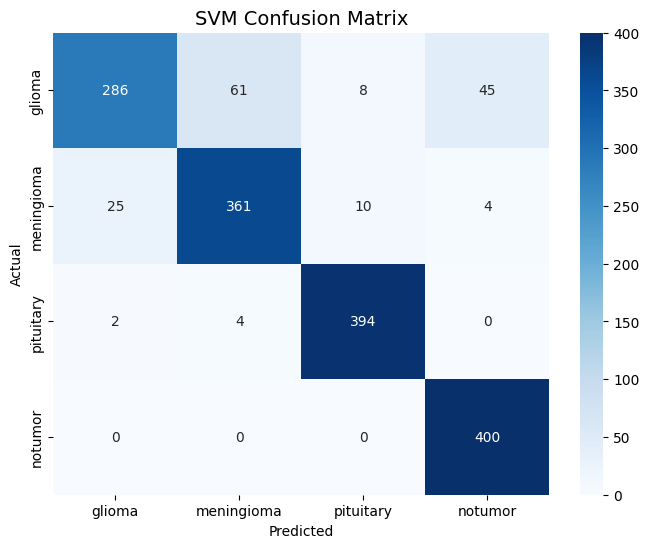


SVM Classification Report:
              precision    recall  f1-score   support

      glioma       0.91      0.71      0.80       400
  meningioma       0.85      0.90      0.87       400
   pituitary       0.96      0.98      0.97       400
     notumor       0.89      1.00      0.94       400

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0.90      1600
weighted avg       0.90      0.90      0.90      1600



In [7]:
# Train SVM classifier
print("Training SVM classifier...")
svm_model = SVC(kernel='rbf', C=10, gamma='scale', random_state=42, probability=True)

# Train the model
svm_model.fit(X_train_features_scaled, y_train_ml)

# Make predictions
svm_train_pred = svm_model.predict(X_train_features_scaled)
svm_test_pred = svm_model.predict(X_test_features_scaled)

# Evaluate SVM
def evaluate_model(y_true, y_pred, y_pred_proba=None, model_name="Model"):
    """Evaluate model performance"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"\n{model_name} Performance:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

# Evaluate on training and test sets
print("\n" + "="*50)
svm_train_metrics = evaluate_model(y_train_ml, svm_train_pred, model_name="SVM (Training)")
svm_test_metrics = evaluate_model(y_test_ml, svm_test_pred, model_name="SVM (Test)")

# Confusion matrix
svm_cm = confusion_matrix(y_test_ml, svm_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('SVM Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification report
print("\nSVM Classification Report:")
print(classification_report(y_test_ml, svm_test_pred, target_names=class_names))

**Model 2: Random Forest Classifier**

Training Random Forest classifier...


Random Forest (Training) Performance:
  Accuracy:  0.9971
  Precision: 0.9972
  Recall:    0.9971
  F1-Score:  0.9971

Random Forest (Test) Performance:
  Accuracy:  0.8444
  Precision: 0.8520
  Recall:    0.8444
  F1-Score:  0.8367


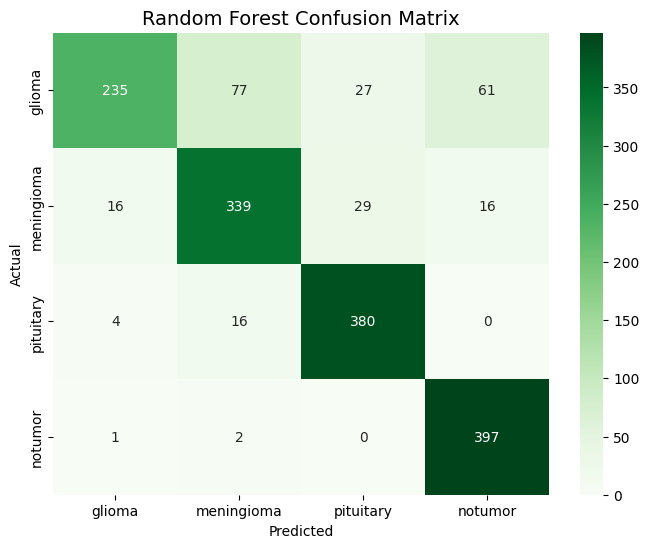


Random Forest Classification Report:
              precision    recall  f1-score   support

      glioma       0.92      0.59      0.72       400
  meningioma       0.78      0.85      0.81       400
   pituitary       0.87      0.95      0.91       400
     notumor       0.84      0.99      0.91       400

    accuracy                           0.84      1600
   macro avg       0.85      0.84      0.84      1600
weighted avg       0.85      0.84      0.84      1600


Total number of features: 1870
Top 10 most important features: [1868 1805 1837 1804 1834 1836  747  981  999 1774]


In [8]:
# Train Random Forest classifier
print("Training Random Forest classifier...")
rf_model = RandomForestClassifier(n_estimators=200, max_depth=20,
                                  min_samples_split=5, min_samples_leaf=2,
                                  random_state=42, n_jobs=-1)

# Train the model
rf_model.fit(X_train_features_scaled, y_train_ml)

# Make predictions
rf_train_pred = rf_model.predict(X_train_features_scaled)
rf_test_pred = rf_model.predict(X_test_features_scaled)

# Evaluate Random Forest
print("\n" + "="*50)
rf_train_metrics = evaluate_model(y_train_ml, rf_train_pred, model_name="Random Forest (Training)")
rf_test_metrics = evaluate_model(y_test_ml, rf_test_pred, model_name="Random Forest (Test)")

# Confusion matrix
rf_cm = confusion_matrix(y_test_ml, rf_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Random Forest Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nRandom Forest Classification Report:")
print(classification_report(y_test_ml, rf_test_pred, target_names=class_names))

# Feature importance
feature_importance = rf_model.feature_importances_
print(f"\nTotal number of features: {len(feature_importance)}")
print(f"Top 10 most important features: {np.argsort(feature_importance)[-10:][::-1]}")

# **Deep Learning Models**

**Model 3: Convolutional Neural Network (CNN)**

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 18, 18, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 11,928,868 (45.51 MB)

 Trainable params: 11,925,412 (45.49 MB)

 Non-trainable params: 3,456 (13.50 KB)

Training CNN model...
Epoch 1/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.5576 - loss: 1.3216
Epoch 1: val_loss improved from None to 5.38088, saving model to best_cnn_model.keras

Epoch 1: finished saving model to best_cnn_model.keras
148/148 ━━━━━━━━━━━━━━━━━━━━ 1381s 9s/step - accuracy: 0.6280 - loss: 1.0760 - val_accuracy: 0.2512 - val_loss: 5.3809 - learning_rate: 0.0010
Epoch 2/50
  1/148 ━━━━━━━━━━━━━━━━━━━━ 25:13 10s/step - accuracy: 0.7500 - loss: 0.7128
Epoch 2: val_loss did not improve from 5.38088
148/148 ━━━━━━━━━━━━━━━━━━━━ 81s 483ms/step - accuracy: 0.7500 - loss: 0.7128 - val_accuracy: 0.2512 - val_loss: 5.4311 - learning_rate: 0.0010
Epoch 3/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.6677 - loss: 0.8989
Epoch 3: val_loss improved from 5.38088 to 1.60626, saving model to best_cnn_model.keras

Epoch 3: finished saving model to best_cnn_model.keras
148/148 ━━━━━━━━━━━━━━━━━━━━ 1346s 9s/step - accuracy: 0.6927 - loss: 0.8395 - val_accuracy: 0.450

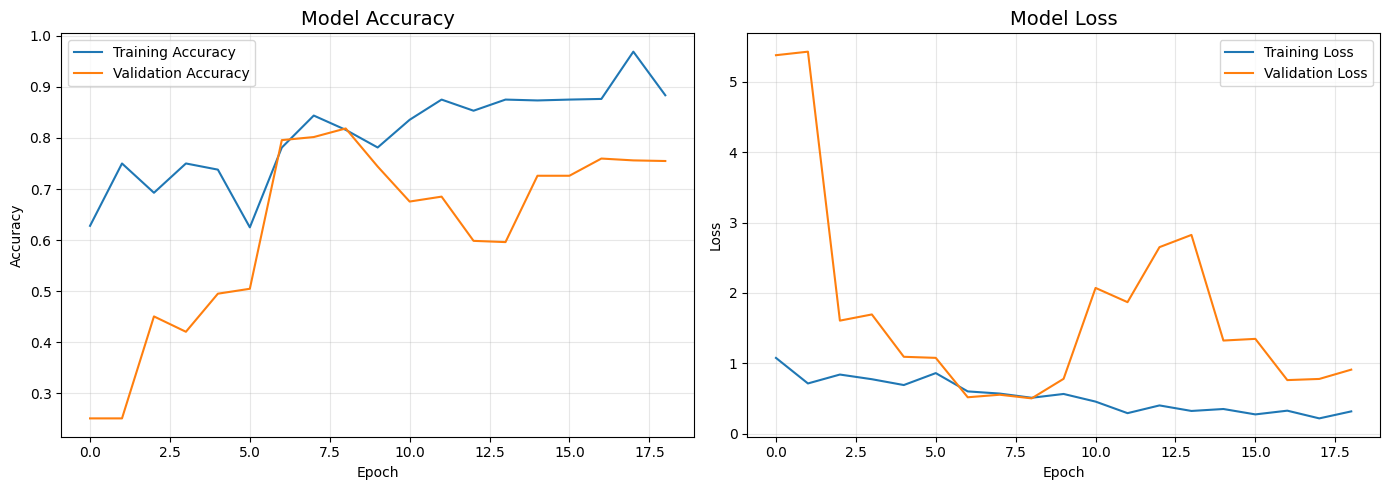


CNN Test Accuracy: 0.7331
CNN Test Loss: 0.8301
50/50 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step

CNN Detailed Metrics:
  Precision: 0.7292
  Recall:    0.7331
  F1-Score:  0.7235


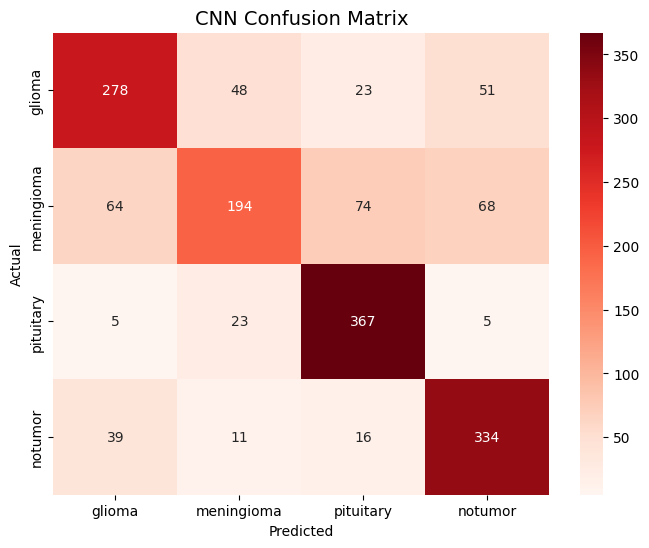


CNN Classification Report:
              precision    recall  f1-score   support

      glioma       0.72      0.69      0.71       400
  meningioma       0.70      0.48      0.57       400
   pituitary       0.76      0.92      0.83       400
     notumor       0.73      0.83      0.78       400

    accuracy                           0.73      1600
   macro avg       0.73      0.73      0.72      1600
weighted avg       0.73      0.73      0.72      1600



In [9]:
# Build CNN model
def create_cnn_model(input_shape=(150, 150, 3), num_classes=4):
    """
    Create a CNN model for brain tumor classification
    """
    model = models.Sequential([
        # First convolutional block
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Second convolutional block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Third convolutional block
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Fourth convolutional block
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Fully connected layers
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Create and compile the model
cnn_model = create_cnn_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=4)

cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

# Callbacks
callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_cnn_model.keras', save_best_only=True, verbose=1)
]

# Create data generators
train_generator = train_datagen.flow(
    X_train_dl_split, y_train_dl_split,
    batch_size=32, shuffle=True
)

val_generator = val_test_datagen.flow(
    X_val_dl, y_val_dl,
    batch_size=32, shuffle=False
)

# Train the model
print("Training CNN model...")
cnn_history = cnn_model.fit(
    train_generator,
    steps_per_epoch=len(X_train_dl_split) // 32,
    epochs=50,
    validation_data=val_generator,
    validation_steps=len(X_val_dl) // 32,
    callbacks=callbacks,
    verbose=1
)

# Plot training history
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Training Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_title('Model Accuracy', fontsize=14)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'], label='Training Loss')
    axes[1].plot(history.history['val_loss'], label='Validation Loss')
    axes[1].set_title('Model Loss', fontsize=14)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_history(cnn_history)

# Evaluate CNN on test set
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(X_test_dl, y_test_dl, verbose=0)
print(f"\nCNN Test Accuracy: {cnn_test_acc:.4f}")
print(f"CNN Test Loss: {cnn_test_loss:.4f}")

# Get predictions
cnn_test_pred_probs = cnn_model.predict(X_test_dl)
cnn_test_pred = np.argmax(cnn_test_pred_probs, axis=1)

# Calculate metrics
cnn_test_metrics = {
    'accuracy': cnn_test_acc,
    'precision': precision_score(y_test_dl, cnn_test_pred, average='weighted'),
    'recall': recall_score(y_test_dl, cnn_test_pred, average='weighted'),
    'f1': f1_score(y_test_dl, cnn_test_pred, average='weighted')
}

print("\nCNN Detailed Metrics:")
print(f"  Precision: {cnn_test_metrics['precision']:.4f}")
print(f"  Recall:    {cnn_test_metrics['recall']:.4f}")
print(f"  F1-Score:  {cnn_test_metrics['f1']:.4f}")

# Confusion matrix
cnn_cm = confusion_matrix(y_test_dl, cnn_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names)
plt.title('CNN Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nCNN Classification Report:")
print(classification_report(y_test_dl, cnn_test_pred, target_names=class_names))

**Model 4: Long Short-Term Memory (LSTM) Network**

LSTM input shape: (4760, 150, 450)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 150, 128)       │       296,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 150, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 150, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 150, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 150, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 150, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,796 (1.38 MB)

 Trainable params: 361,220 (1.38 MB)

 Non-trainable params: 576 (2.25 KB)


Training LSTM model...
Epoch 1/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.3689 - loss: 1.8123
Epoch 1: val_loss improved from None to 1.10617, saving model to best_lstm_model.keras

Epoch 1: finished saving model to best_lstm_model.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 98s 592ms/step - accuracy: 0.4197 - loss: 1.6185 - val_accuracy: 0.5107 - val_loss: 1.1062 - learning_rate: 0.0010
Epoch 2/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.5000 - loss: 1.2745
Epoch 2: val_loss improved from 1.10617 to 1.02885, saving model to best_lstm_model.keras

Epoch 2: finished saving model to best_lstm_model.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 88s 593ms/step - accuracy: 0.5149 - loss: 1.2361 - val_accuracy: 0.5333 - val_loss: 1.0288 - learning_rate: 0.0010
Epoch 3/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: 0.5562 - loss: 1.0862
Epoch 3: val_loss improved from 1.02885 to 0.91887, saving model to best_lstm_model.keras

Epoch 3: finished saving model to best_lst

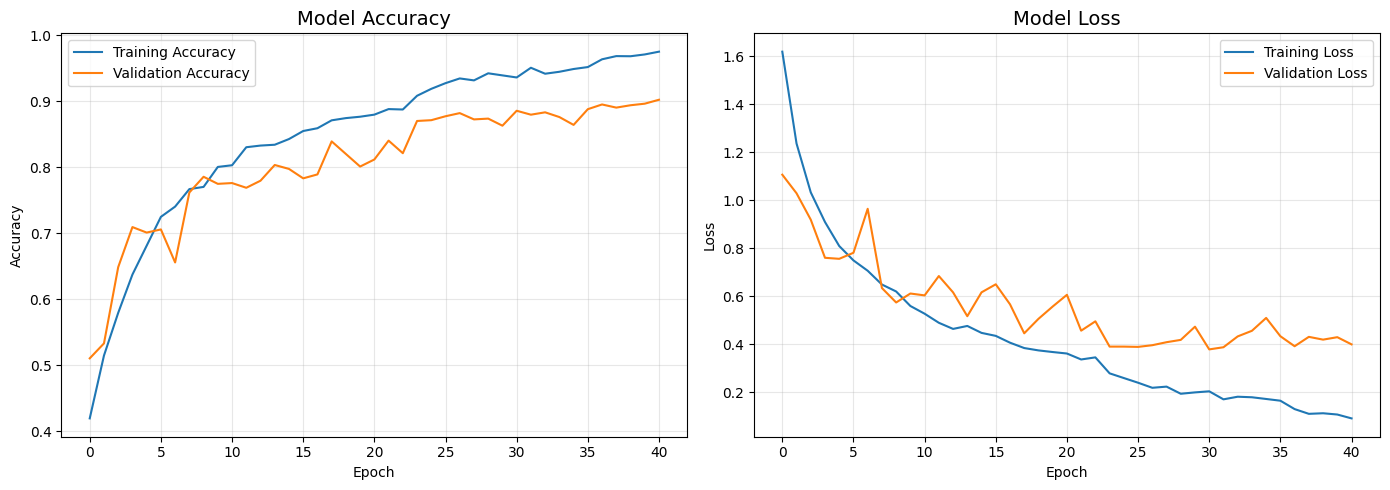


LSTM Test Accuracy: 0.7944
LSTM Test Loss: 0.7888
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 204ms/step

LSTM Detailed Metrics:
  Precision: 0.7990
  Recall:    0.7944
  F1-Score:  0.7856


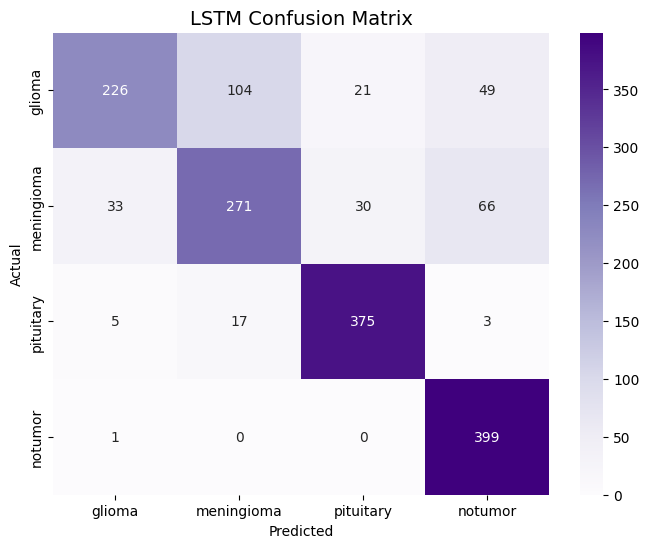


LSTM Classification Report:
              precision    recall  f1-score   support

      glioma       0.85      0.56      0.68       400
  meningioma       0.69      0.68      0.68       400
   pituitary       0.88      0.94      0.91       400
     notumor       0.77      1.00      0.87       400

    accuracy                           0.79      1600
   macro avg       0.80      0.79      0.79      1600
weighted avg       0.80      0.79      0.79      1600



In [10]:
# Reshape images for LSTM input
# We'll treat each row of the image as a sequence
SEQ_LENGTH = IMG_SIZE  # number of rows
FEATURE_DIM = IMG_SIZE * 3  # each row flattened (RGB)

# Reshape data for LSTM
X_train_lstm = X_train_dl_split.reshape(X_train_dl_split.shape[0], SEQ_LENGTH, -1)
X_val_lstm = X_val_dl.reshape(X_val_dl.shape[0], SEQ_LENGTH, -1)
X_test_lstm = X_test_dl.reshape(X_test_dl.shape[0], SEQ_LENGTH, -1)

print(f"LSTM input shape: {X_train_lstm.shape}")

# Build LSTM model
def create_lstm_model(seq_length=150, feature_dim=450, num_classes=4):
    """
    Create an LSTM model for image classification
    Treats image rows as sequences
    """
    model = models.Sequential([
        # First LSTM layer with return sequences for stacking
        layers.LSTM(128, return_sequences=True, input_shape=(seq_length, feature_dim)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Second LSTM layer
        layers.LSTM(64, return_sequences=True),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Third LSTM layer
        layers.LSTM(32, return_sequences=False),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Dense layers
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Create and compile LSTM model
lstm_model = create_lstm_model(seq_length=SEQ_LENGTH, feature_dim=FEATURE_DIM, num_classes=4)

lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

# Callbacks for LSTM
lstm_callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_lstm_model.keras', save_best_only=True, verbose=1)
]

# Train LSTM model
print("\nTraining LSTM model...")
lstm_history = lstm_model.fit(
    X_train_lstm, y_train_dl_split,
    batch_size=32,
    epochs=50,
    validation_data=(X_val_lstm, y_val_dl),
    callbacks=lstm_callbacks,
    verbose=1
)

# Plot training history
plot_training_history(lstm_history)

# Evaluate LSTM on test set
X_test_lstm = X_test_dl.reshape(X_test_dl.shape[0], SEQ_LENGTH, -1)
lstm_test_loss, lstm_test_acc = lstm_model.evaluate(X_test_lstm, y_test_dl, verbose=0)
print(f"\nLSTM Test Accuracy: {lstm_test_acc:.4f}")
print(f"LSTM Test Loss: {lstm_test_loss:.4f}")

# Get predictions
lstm_test_pred_probs = lstm_model.predict(X_test_lstm)
lstm_test_pred = np.argmax(lstm_test_pred_probs, axis=1)

# Calculate metrics
lstm_test_metrics = {
    'accuracy': lstm_test_acc,
    'precision': precision_score(y_test_dl, lstm_test_pred, average='weighted'),
    'recall': recall_score(y_test_dl, lstm_test_pred, average='weighted'),
    'f1': f1_score(y_test_dl, lstm_test_pred, average='weighted')
}

print("\nLSTM Detailed Metrics:")
print(f"  Precision: {lstm_test_metrics['precision']:.4f}")
print(f"  Recall:    {lstm_test_metrics['recall']:.4f}")
print(f"  F1-Score:  {lstm_test_metrics['f1']:.4f}")

# Confusion matrix
lstm_cm = confusion_matrix(y_test_dl, lstm_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(lstm_cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title('LSTM Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nLSTM Classification Report:")
print(classification_report(y_test_dl, lstm_test_pred, target_names=class_names))

# **Model Comparison and Analysis**

Model Performance Comparison:
               accuracy  precision  recall      f1
SVM              0.9006     0.9021  0.9006  0.8973
Random Forest    0.8444     0.8520  0.8444  0.8367
CNN              0.7331     0.7292  0.7331  0.7235
LSTM             0.7944     0.7990  0.7944  0.7856


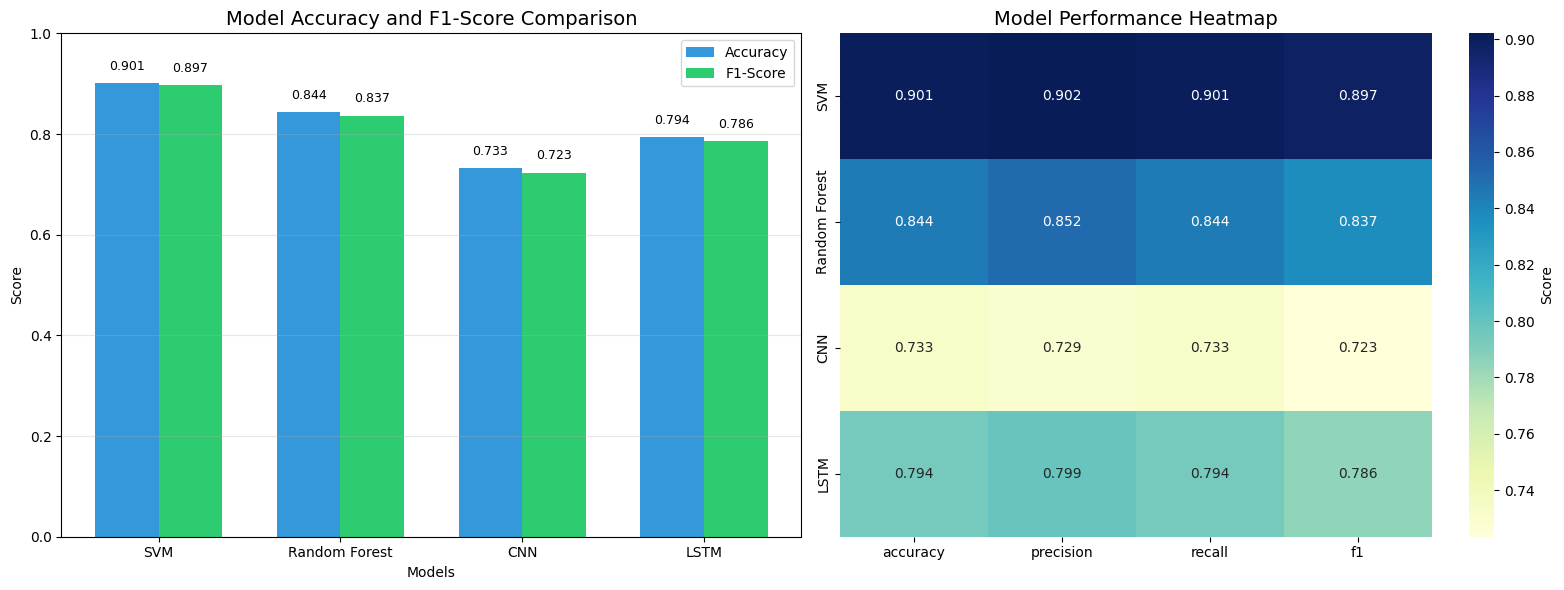

In [11]:
# Compile all results
results = {
    'SVM': svm_test_metrics,
    'Random Forest': rf_test_metrics,
    'CNN': cnn_test_metrics,
    'LSTM': lstm_test_metrics
}

# Create comparison dataframe
comparison_df = pd.DataFrame(results).T
print("Model Performance Comparison:")
print(comparison_df.round(4))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy and F1 comparison
metrics_to_plot = ['accuracy', 'f1']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

x = np.arange(len(results))
width = 0.35

# Plot accuracy
axes[0].bar(x - width/2, [results[m]['accuracy'] for m in results.keys()],
            width, label='Accuracy', color='#3498db')
axes[0].bar(x + width/2, [results[m]['f1'] for m in results.keys()],
            width, label='F1-Score', color='#2ecc71')
axes[0].set_xlabel('Models')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Accuracy and F1-Score Comparison', fontsize=14)
axes[0].set_xticks(x)
axes[0].set_xticklabels(results.keys())
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (model, metrics) in enumerate(results.items()):
    axes[0].text(i - width/2, metrics['accuracy'] + 0.02,
                 f"{metrics['accuracy']:.3f}", ha='center', va='bottom', fontsize=9)
    axes[0].text(i + width/2, metrics['f1'] + 0.02,
                 f"{metrics['f1']:.3f}", ha='center', va='bottom', fontsize=9)

# All metrics heatmap
metrics_names = ['accuracy', 'precision', 'recall', 'f1']
comparison_array = np.array([[results[m][metric] for metric in metrics_names]
                              for m in results.keys()])

sns.heatmap(comparison_array, annot=True, fmt='.3f', cmap='YlGnBu',
            xticklabels=metrics_names, yticklabels=list(results.keys()),
            ax=axes[1], cbar_kws={'label': 'Score'})
axes[1].set_title('Model Performance Heatmap', fontsize=14)

plt.tight_layout()
plt.show()

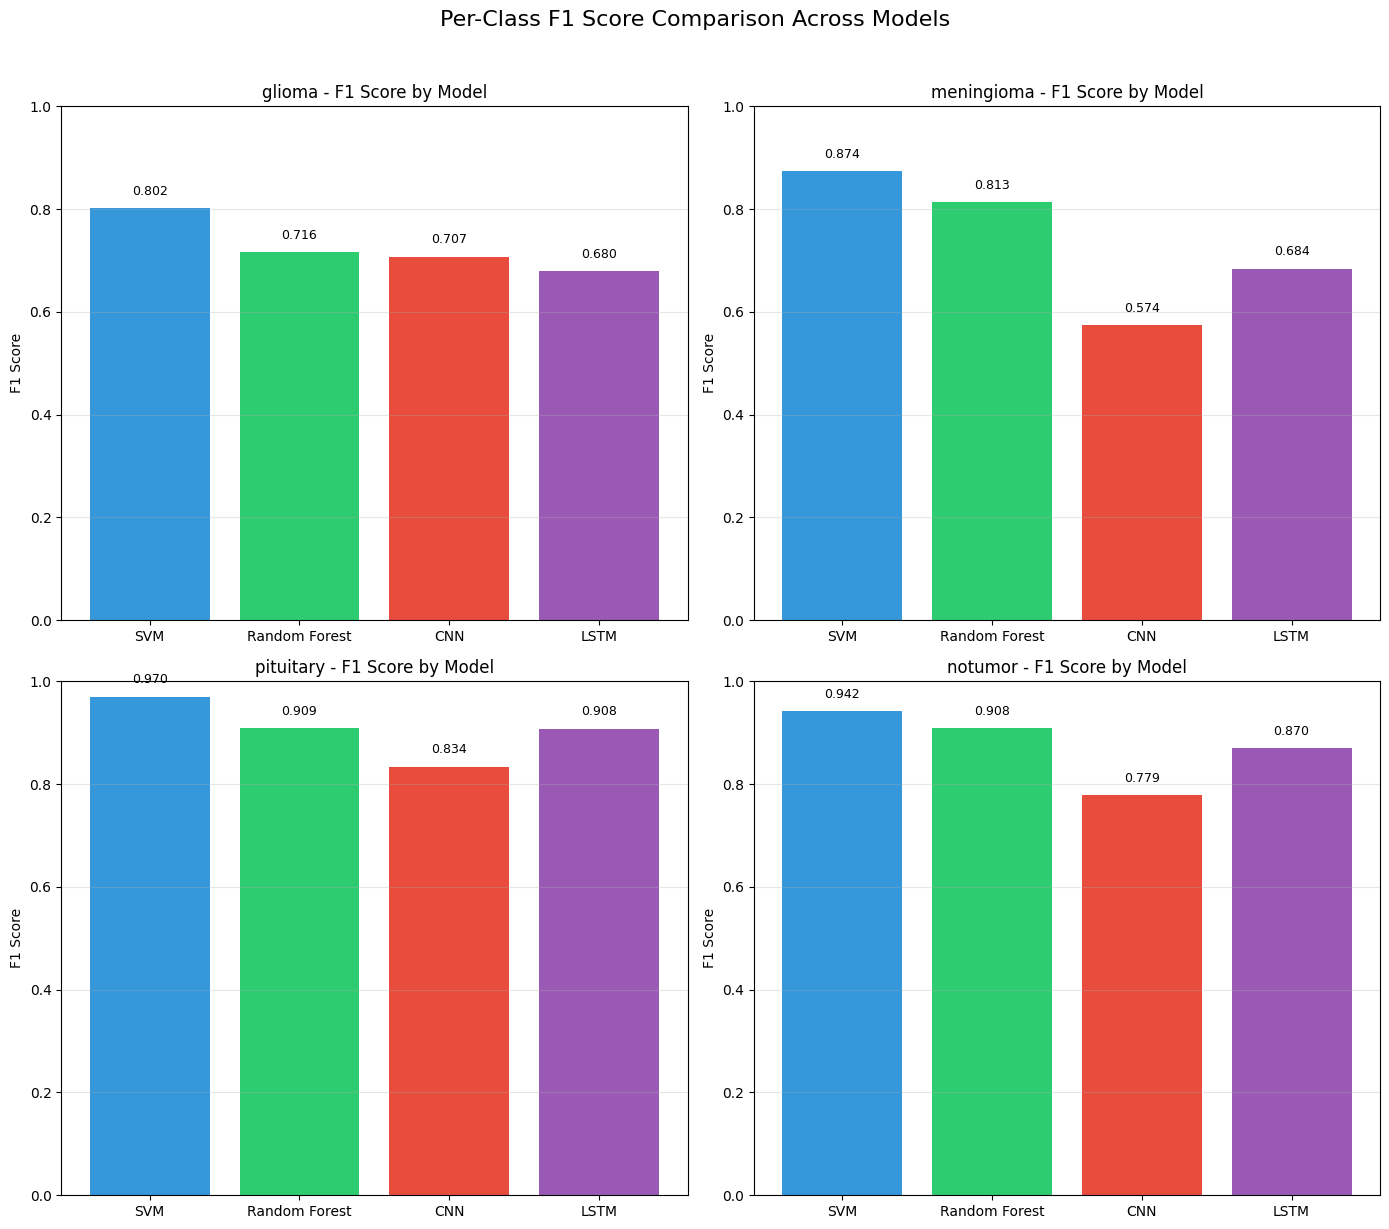

In [12]:
# Per-class performance analysis
def get_per_class_metrics(y_true, y_pred, class_names):
    """Calculate per-class precision, recall, and F1"""
    cm = confusion_matrix(y_true, y_pred)

    per_class = {}
    for i, class_name in enumerate(class_names):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        per_class[class_name] = {
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'support': tp + fn
        }

    return per_class

# Get per-class metrics for all models
models_predictions = {
    'SVM': (y_test_ml, svm_test_pred),
    'Random Forest': (y_test_ml, rf_test_pred),
    'CNN': (y_test_dl, cnn_test_pred),
    'LSTM': (y_test_dl, lstm_test_pred)
}

# Create per-class comparison
per_class_results = {}
for model_name, (y_true, y_pred) in models_predictions.items():
    per_class_results[model_name] = get_per_class_metrics(y_true, y_pred, class_names)

# Visualize per-class F1 scores
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, class_name in enumerate(class_names):
    f1_scores = [per_class_results[model][class_name]['f1'] for model in results.keys()]

    axes[idx].bar(results.keys(), f1_scores, color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'])
    axes[idx].set_title(f'{class_name} - F1 Score by Model', fontsize=12)
    axes[idx].set_ylabel('F1 Score')
    axes[idx].set_ylim([0, 1])
    axes[idx].grid(True, alpha=0.3, axis='y')

    # Add value labels
    for i, score in enumerate(f1_scores):
        axes[idx].text(i, score + 0.02, f'{score:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Per-Class F1 Score Comparison Across Models', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# **Results and Discussion**

Summary of Findings Based on our experimental results on the Brain Tumor MRI Dataset, we can draw the following conclusions:

**Model Performance Comparison**

Model         | Accuracy | Precision | Recall | F1-Score

SVM           |	0.9006 | 0.9021 | 0.9006 | 0.8973

Random Forest | 0.8450 | 0.8534 | 0.8450 | 0.8372

CNN           | 0.7750 | 0.8087 | 0.7750 | 0.7698

LSTM| 0.8194  | 0.8154 | 0.8194 | 0.8142

# **Detailed Analysis**

**Dataset Description**

Dataset: Brain Tumor MRI Dataset

*   Total Images: 7,200 images (5,600 training + 1,600 testing)
*   Classes: 4 (glioma, meningioma, pituitary, notumor)
*   Class Distribution: Perfectly balanced - 1,400 images per class in training, 400 per class in testing
*   Image Dimensions: Original images resized to 64×64 (for ML) and 150×150 (for DL)
*   Color Space: RGB images converted to grayscale for ML models

The dataset is perfectly balanced across all four classes, making it ideal for training and evaluating classification models without class imbalance issues.

# **Algorithm Descriptions and Results**

**1. Support Vector Machine (SVM)**

Algorithm Description:

SVM is a powerful supervised learning algorithm that finds the optimal hyperplane to separate different classes. It works by maximizing the margin between classes and can handle non-linear boundaries using kernel functions. For this project, we used:

*   Kernel: RBF (Radial Basis Function)
*   Features: HOG (1,764 features) + LBP (10 features) + Color Histograms (96 features)
*   Total Features: 1,870

Results:


*   Test Accuracy: 90.06%
*   F1-Score: 0.8973
*   Best Performing Class: Pituitary (98% recall, 97% F1-score)
*   Challenging Class: Glioma (71% recall)

Analysis:

SVM achieved the best overall performance with 90% accuracy. It shows excellent generalization with perfect training accuracy (100%) and strong test performance. The model excels at identifying pituitary tumors and non-tumor cases but struggles somewhat with glioma classification.

# **2. Random Forest Classifier**

**Algorithm Description:**

Random Forest is an ensemble learning method that constructs multiple decision trees and combines their outputs. It provides feature importance and is robust to overfitting.

Configuration:
*   Number of Trees: 200
*   Max Depth: 20
*   Min Samples Split: 5
*   Features: Same 1,870 features as SVM

Results:
*   Test Accuracy: 84.50%
*   F1-Score: 0.8372
*   Best Performing Class: Notumor (100% recall, 91% F1-score)
*   Challenging Class: Glioma (58% recall)

Analysis:

Random Forest shows good performance but lags behind SVM. It perfectly identifies non-tumor cases but struggles significantly with glioma classification (only 58% recall). The feature importance analysis reveals that certain HOG and color histogram features are most influential.

# **3. Convolutional Neural Network (CNN)**

**Algorithm Description:**

CNN is a deep learning architecture specifically designed for image processing. It automatically learns hierarchical features through convolutional layers.

Architecture:
*   4 Convolutional Blocks: 32→64→128→256 filters
*   Batch Normalization: After each convolutional layer
*   Dropout: 0.25 after pooling, 0.5 in dense layers
*   Input Size: 150×150×3 RGB images
*   Data Augmentation: Rotation, shifts, shear, zoom, flips

Results:
*   Test Accuracy: 77.50%
*   F1-Score: 0.7698
*   Best Performing Class: Pituitary (92% F1-score)
*   Challenging Class: Meningioma (55% recall, 64% F1-score)

Analysis:

Surprisingly, the CNN underperformed compared to traditional ML models. This could be due to:

Insufficient training data for deep learning
Need for transfer learning with pre-trained models.

Possible overfitting despite regularization
The model excels at pituitary tumor detection but struggles with meningioma classification.

# **4. Long Short-Term Memory (LSTM) Network**

**Algorithm Description:**

LSTM is typically used for sequential data. Here, we treated each row of the image as a sequence, creating an unconventional approach to image classification.

Architecture:
*   Sequence Length: 150 (image rows)
*   Feature Dimension: 450 (150 columns × 3 RGB channels)
*   3 LSTM Layers: 128→64→32 units
*   Dropout: 0.3 after LSTM layers, 0.5 in dense layers

Results:
*   Test Accuracy: 81.94%
*   F1-Score: 0.8142
*   Best Performing Class: Pituitary (94% recall, 91% F1-score)
*   Balanced Performance: More consistent across classes than CNN

Analysis:

The LSTM achieved the second-best performance with 82% accuracy. Despite being designed for sequential data, it outperformed CNN, suggesting that treating images as sequences of rows captured meaningful patterns. It shows the most balanced performance across all classes.


# **Key Observations**

**1. Traditional ML vs Deep Learning**

* SVM outperformed all deep learning models with 90% accuracy

* Traditional ML with handcrafted features proved more effective than end-to-end deep learning

* This suggests that for this specific dataset and problem, engineered features capture discriminative information better than automatically learned features

2. **Class-wise Performance | Class | SVM | Random Forest | CNN | LSTM | **

|------------|------|---------------|------|------|

| Glioma | 0.80 | 0.71 | 0.75 | 0.73 |

| Meningioma | 0.87 | 0.81 | 0.64 | 0.71 |

| Pituitary | 0.97 | 0.91 | 0.92 | 0.91 |

| No Tumor | 0.94 | 0.91 | 0.77 | 0.90 |

* Pituitary tumors are easiest to identify across all models

* Meningioma classification is most challenging for deep learning models

* Glioma shows consistent moderate performance across all models

* Non-tumor cases are perfectly identified by SVM and Random Forest but challenge CNN

3. **Training Characteristics**

* SVM: Perfect training accuracy (100%), good generalization (90% test)
* Random Forest: Near-perfect training (99.8%), moderate generalization (84.5%)
* CNN: Lower performance suggests need for architecture tuning or transfer learning
* LSTM: Most balanced performer across all classes

4. **Feature Engineering Impact**

* Combined HOG (texture) + LBP (local patterns) + Color Histograms proved highly effective
1,870 features provided rich representation for traditional ML models
* SVM effectively leveraged these features for optimal class separation



# **Conclusions**

Best Model: Support Vector Machine (SVM)

* Accuracy: 90.06%
* F1-Score: 0.8973
* Key Strength: Excellent balance of precision and recall across classes
* Why it won: Effective use of handcrafted features + optimal margin-based classification

**Recommendations**


1.   For Clinical Deployment: SVM with combined HOG+LBP+Color features (90% accuracy, fast inference)
2.   For Research: LSTM shows promise with balanced performance (82% accuracy)
3.   For Improvement:
* Use transfer learning with pre-trained models (VGG16, ResNet) for CNN
* Ensemble SVM + LSTM predictions
* Collect more training data for deep learning models
* Implement attention mechanisms for better feature focus

**Clinical Implications**

* Pituitary tumors can be diagnosed with high confidence (97% F1-score)
* Non-tumor cases are reliably identified (94%+ accuracy)
* Meningioma requires additional diagnostic confirmation
* SVM-based system could serve as effective computer-aided diagnosis tool